## 🛠️ Setup & Imports

In [1]:
!nvidia-smi

Tue Apr 21 10:56:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   25C    P8             24W /  300W |       1MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [ ]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # → consistency/  (pour consistency_models)
sys.path.append('../../..')  # → 4dvarnet-starter-devs/  (pour src)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring non installé — CRPS désactivé. Installer avec: pip install properscoring")

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

In [4]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


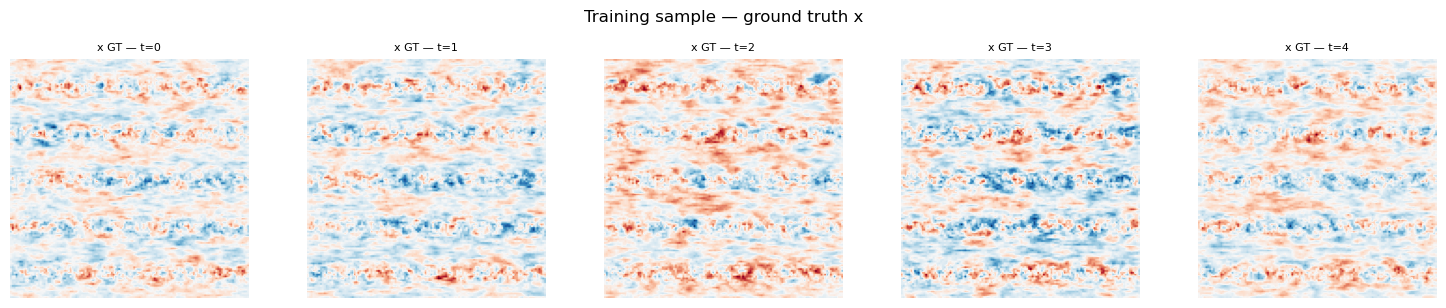

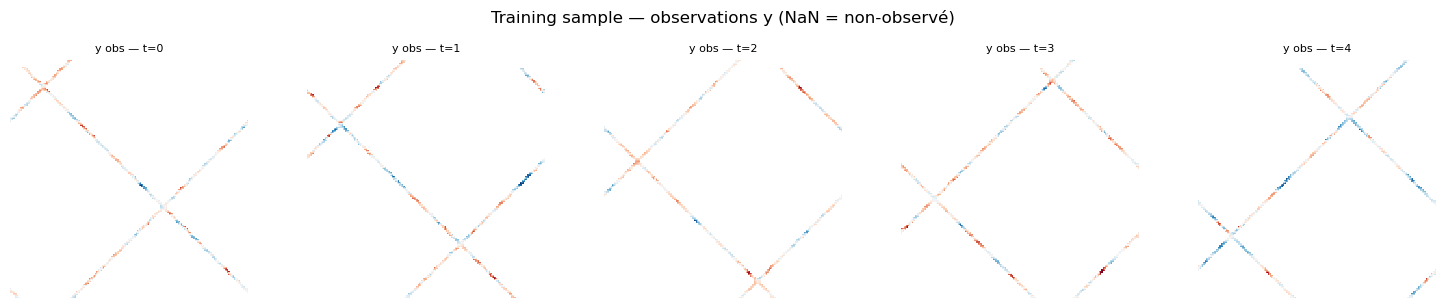

In [5]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth x", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — observations y (NaN = non-observé)", y=1.01)
plt.tight_layout()
plt.show()

### Building Blocks du UNet

Identiques au notebook PWCM SSH (GroupNorm, SelfAttention, UNetBlock, Downsample, Upsample, TimeLevelEmbedding).

In [6]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (pour gérer 100×100 → 104×104, multiple de 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)  # left, right, top, bottom
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet (Consistency Model)

Le UNet prend en entrée la concaténation `(x_noisy, y_filled, mask_obs)` → `3×C` canaux d'entrée.  
Conditionné par deux embeddings temporels `σ` et `σ'` (concaténés → `2×time_level_channels`).  
Un padding réflexion à multiple de 8 est appliqué en entrée et retiré en sortie.

In [7]:
@dataclass
class UNetConfig:
    channels: int = 5                                        # = window_size
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config

        # input = (x_noisy, y_filled, mask_obs) → 3 * channels
        self.input_projection = nn.Conv2d(
            config.channels * 3,
            config.top_blocks_channels[0],
            kernel_size=3, padding="same",
        )
        self.time_level_embedding = TimeLevelEmbedding(
            config.time_level_channels, config.time_level_scale
        )

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(
            config.top_blocks_channels[0], config.channels, kernel_size=3, padding="same"
        )

    def forward(self, x: Tensor, y: Tensor, time: Tensor, time_prime: Tensor) -> Tensor:
        mask_obs = (~torch.isnan(y)).to(x.dtype)
        y_filled = torch.nan_to_num(y, nan=0.0)

        # Pad H×W to nearest multiple of 8 (100×100 → 104×104)
        inp = torch.cat((x, y_filled, mask_obs), dim=1)   # (B, 3C, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)

        # Two sigma embeddings concatenated along channel dim
        emb1 = self.time_level_embedding(time)
        emb2 = self.time_level_embedding(time_prime)
        time_level = torch.cat([emb1, emb2], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)   # restaure H×W original

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# Sanity check : 100×100 sera paddé à 104×104 en interne
C = datamodule.window_size
summary(
    UNet(UNetConfig(channels=C)),
    input_size=(
        (1, C, 100, 100),  # x_noisy
        (1, C, 100, 100),  # y_obs
        (1,),               # sigma
        (1,),               # sigma_prime
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 64, 104, 104]         8,704
├─TimeLevelEmbedding: 1-2                     [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─TimeLevelEmbedding: 1-3                     [1, 128, 1, 1]            (recursive)
│    └─Sequential: 2-2                        [1, 128, 1, 1]            (recursive)
│    │    └─Linear: 3-5                       [1, 512]                  (recursive)
│    │    └─SiLU: 3-6                         [1, 512]   

### LightningModule — LitConsistencyModel

Identique au notebook PWCM SSH. Le `training_step` appelle `ConsistencyTrainingFewSteps_TimeEmbedding` avec `batch.tgt` (vérité terrain) et `batch.input` (observations avec NaN).

In [11]:

@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    eval_nsteps: int = 10   # steps de sampling pour l'évaluation en fin d'epoch


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training: ConsistencyTrainingFewSteps_TimeEmbedding,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps
        self._val_batch = None   # sera rempli dans on_fit_start

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_fit_start(self) -> None:
        """Stocke un batch de validation fixe pour l'évaluation en fin d'epoch."""
        try:
            dl = self.trainer.datamodule.val_dataloader()
            batch = next(iter(dl))
            if isinstance(batch, list):
                batch = batch[0]
            self._val_batch = batch
            print(f"✅ Val batch chargé : tgt={batch.tgt.shape}")
        except Exception as e:
            print(f"⚠️  Impossible de charger un batch de validation : {e}")

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch.tgt,
            batch.input,
            self.global_step,
            10000,
        )
        self.num_timesteps = output.num_timesteps

        if batch_idx == 0:
            print(f"[Epoch {self.current_epoch}] sigmas={output.sigmas}")

        loss = F.mse_loss(
            output.predicted_next_from_intermediate,
            output.target_next_from_current,
        )
        self.log_dict({
            "train_loss":    loss,
            "num_timesteps": float(output.num_timesteps),
        })
        return loss

    def on_train_epoch_end(self) -> None:
        """Calcule le RMSE de reconstruction (10 steps, modèle EMA) sur le batch de validation."""
        if self._val_batch is None:
            print(f"[Epoch {self.current_epoch}]  ⚠️  Pas de batch de validation disponible.")
            return

        device = self.device
        dtype  = next(self.ema_student_model.parameters()).dtype

        x_gt = self._val_batch.tgt.to(device=device, dtype=dtype)
        y    = self._val_batch.input.to(device=device, dtype=dtype)
        B, C, H, W = x_gt.shape

        sampler = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()
        self.ema_student_model.eval()

        with torch.no_grad():
            noise = torch.randn((B, C, H, W), device=device, dtype=dtype)
            x_hat, _ = sampler(
                self.ema_student_model,
                noise,
                y,
                nsteps=self.config.eval_nsteps,
                clip_denoised=False,
                verbose=False,
                stochastic=False,
            )

        rmse = (x_hat.float() - x_gt.float()).pow(2).mean().sqrt().item()
        print(
            f"[Epoch {self.current_epoch}]  "
            f"Val RMSE ({self.config.eval_nsteps} steps, EMA) = {rmse:.4f}"
        )
        self.log("val_rmse_ema", rmse)

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model, self.student_model, ema_decay_rate)
        self.log_dict({"ema_decay_rate": ema_decay_rate})
        update_ema_model_(
            self.ema_student_model,
            self.student_model,
            self.config.student_model_ema_decay_rate,
        )

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.student_model.parameters(),
            lr=self.config.lr, betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


## 🚀 Training

In [9]:
%tensorboard --logdir=logs_CT_CM_spde --port 6007

UsageError: Line magic function `%tensorboard` not found.


In [ ]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"✅ Valid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("❌ No valid checkpoint found. Starting from scratch.")
    return None


C = datamodule.window_size

LOG_DIR     = "logs_CT_CM_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")

resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

ct = ConsistencyTrainingFewSteps_TimeEmbedding(final_timesteps=17)

student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

lit_cm = LitConsistencyModel(
    ct,
    student_model,
    teacher_model,
    ema_student_model,
    LitConsistencyModelConfig(lr_scheduler_iters=1000),
)

trainer = Trainer(
    accelerator="gpu",
    max_epochs=2500,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

# Sauvegarde du modèle EMA
lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
print(f"✅ EMA model saved to: {MODEL_PATH}")

✅ Valid checkpoint: logs_CT_CM_spde/v1/checkpoints/last.ckpt


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
Restoring states from the checkpoint path at logs_CT_CM_spde/v1/checkpoints/last.ckpt
Restoring states from the checkpoint path at logs_CT_CM_spde/v1/checkpoints/last.ckpt


[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name              | Type | Params
-------------------------------------------
0 | student_model     | UNet | 32.9 M
1 | teacher_model     | UNet | 32.9 M
2 | ema_student_model | UNet | 32.9 M
-------------------------------------------
32.9 M    Trainable params
65.7 M    Non-trainable params
98.6 M    Total params
394.414   Total estimated model params size (MB)

  | Name              | Type | Params
-------------------------------------------
0 | student_model     | UNet | 32.9 M
1 | teacher_model     | UNet | 32.9 M
2 | ema_student_model | UNet | 32.9 M
-------------------------------------------
32.9 M    Trainable params
65.7 M    Non-trainable params
98.6 M    Total params
394.414   Total estimated model params size (MB)
Restored all states from the checkpoint at logs_CT_CM_spde/v1/checkpoints/last.ckpt
Restored all states from the checkpoint at logs_CT_CM_spde/v1/checkpoints/last.ckpt


✅ Val batch chargé : tgt=torch.Size([1, 5, 128, 128])


Training: 0it [00:00, ?it/s]

[Epoch 436] num_timesteps=2
[Epoch 436] sigmas=tensor([0.0000, 0.0370, 0.0741, 0.1111, 0.1481, 0.1852, 0.2222, 0.2593, 0.2963,
        0.3333, 0.3704, 0.4074, 0.4444, 0.4815, 0.5185, 0.5556, 0.5926, 0.6296,
        0.6667, 0.7037, 0.7407, 0.7778, 0.8148, 0.8519, 0.8889, 0.9259, 0.9630,
        1.0000], device='cuda:0')
[Epoch 436] sigmas=tensor([0.0000, 0.0370, 0.0741, 0.1111, 0.1481, 0.1852, 0.2222, 0.2593, 0.2963,
        0.3333, 0.3704, 0.4074, 0.4444, 0.4815, 0.5185, 0.5556, 0.5926, 0.6296,
        0.6667, 0.7037, 0.7407, 0.7778, 0.8148, 0.8519, 0.8889, 0.9259, 0.9630,
        1.0000], device='cuda:0')
[Epoch 436]  Val RMSE (10 steps, EMA) = 0.8852
[Epoch 436]  Val RMSE (10 steps, EMA) = 0.8852
[Epoch 437] num_timesteps=28
[Epoch 437] num_timesteps=28
[Epoch 437] sigmas=tensor([0.0000, 0.0370, 0.0741, 0.1111, 0.1481, 0.1852, 0.2222, 0.2593, 0.2963,
        0.3333, 0.3704, 0.4074, 0.4444, 0.4815, 0.5185, 0.5556, 0.5926, 0.6296,
        0.6667, 0.7037, 0.7407, 0.7778, 0.8148, 0.8519,

## 🎲 Sampling & Evaluation

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"✅ Model loaded from: {MODEL_PATH}")

✅ Model loaded from: logs_CT_CM_spde/v1/best_model


### Batch de test

Global seed set to 42


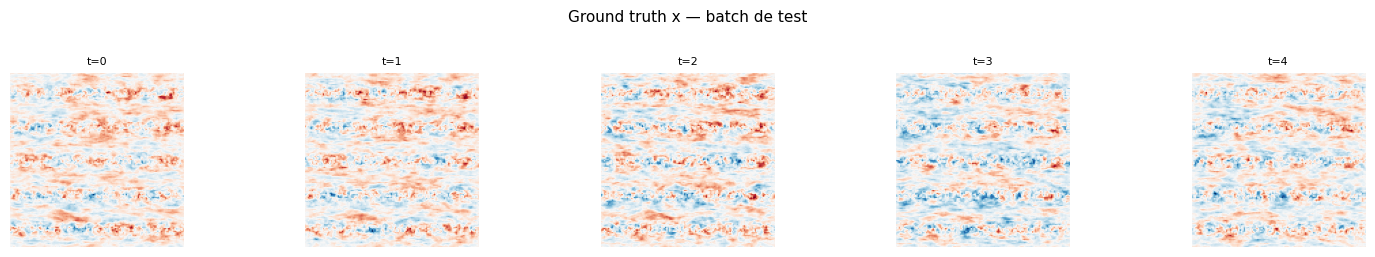

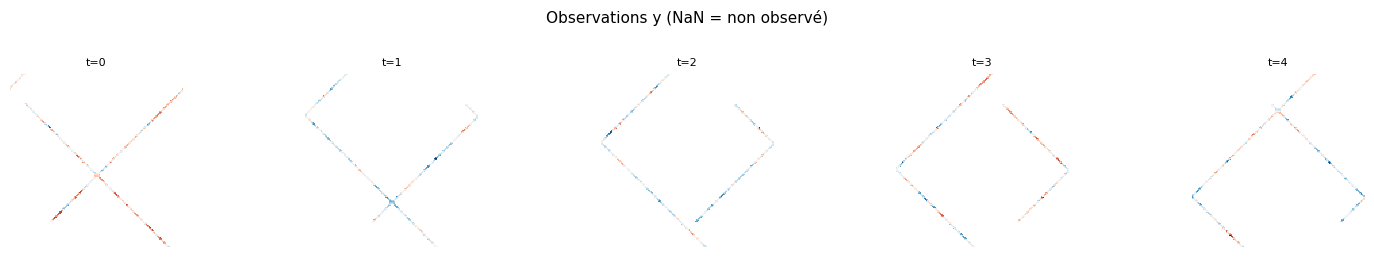

In [ ]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

def plot_field(arr: np.ndarray, title: str = "", vmin=None, vmax=None,
               cols: int = 5, cmap: str = "RdBu_r") -> None:
    """Affiche un champ (T, H, W) sous forme de grille."""
    T = arr.shape[0]
    rows = math.ceil(T / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).ravel()
    for t in range(T):
        im = axes[t].imshow(arr[t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for ax in axes[T:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


plot_field(batch.tgt[0].float().numpy(),   title="Ground truth x — batch de test")
plot_field(batch.input[0].float().numpy(), title="Observations y (NaN = non observé)")

### Génération d'ensemble (N_SAMPLES membres)

  Sample 100/100 done
✅ 100 membres d'ensemble générés


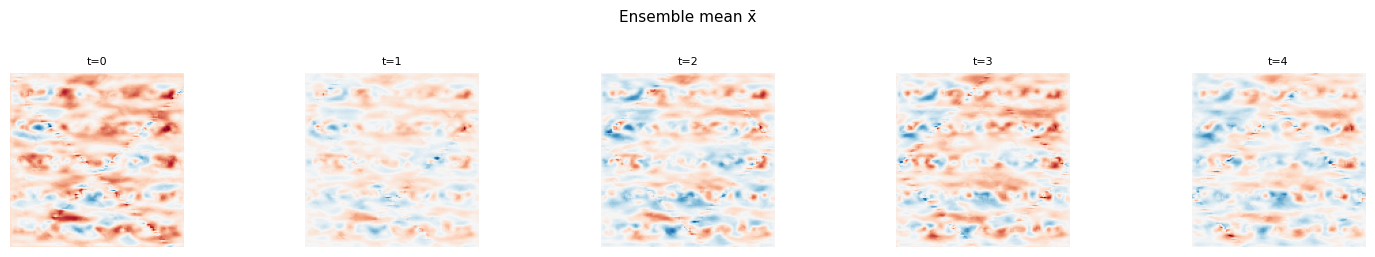

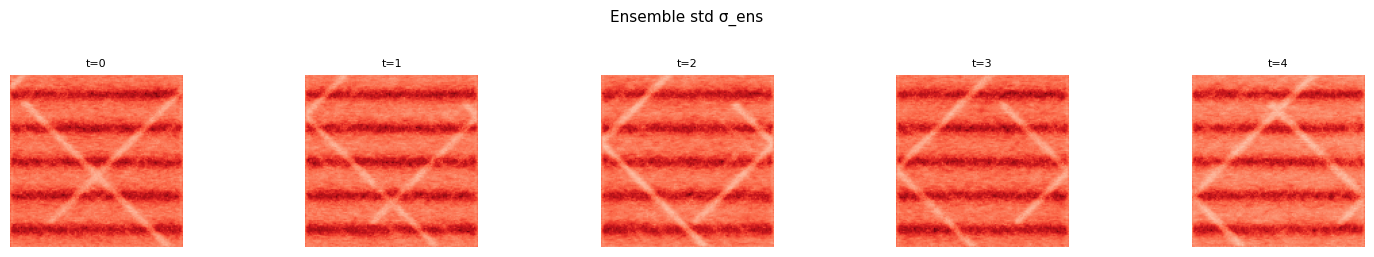

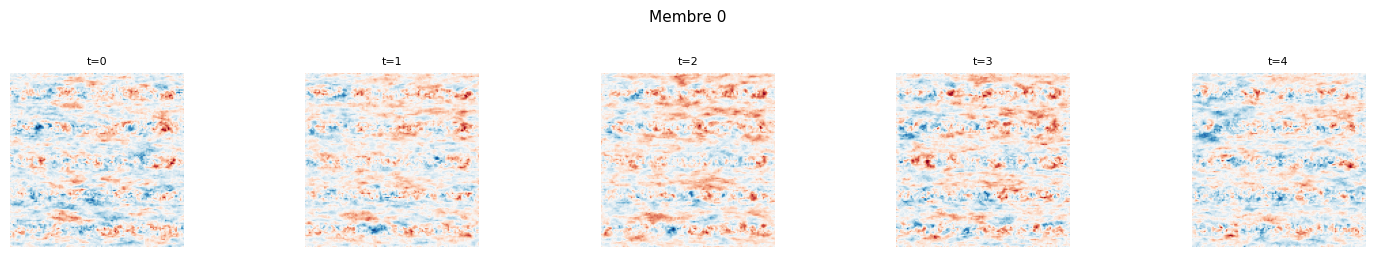

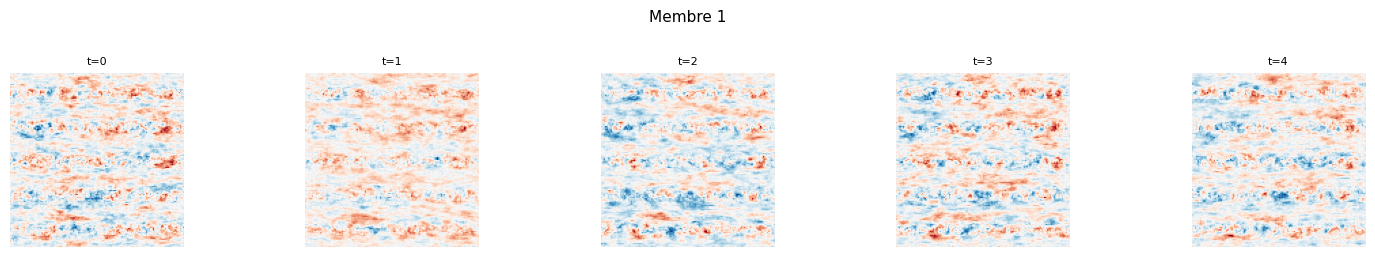

In [ ]:
N_SAMPLES = 100
consistency_sampling = ConsistencySamplingAndEditingFewSteps_TimeEmbedding()

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]  # 100×100

samples = []
samples_process = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        sample, sample_process = consistency_sampling(
            unet,
            torch.randn((1, C, H, W), device=device, dtype=dtype),
            batch.input.to(device=device, dtype=dtype),
            nsteps=15,
            clip_denoised=False,
            verbose=(i == 0),
            stochastic=True,
        )
        samples.append(sample)
        samples_process.append(sample_process)
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n✅ {N_SAMPLES} membres d'ensemble générés")

# Moyenne et écart-type de l'ensemble
ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)                      # (C, H, W)
ens_std  = ensemble.std(dim=0)                       # (C, H, W)

plot_field(ens_mean.float().cpu().numpy(),   title="Ensemble mean x̄")
plot_field(ens_std.float().cpu().numpy(),    title="Ensemble std σ_ens", vmin=0, cmap="Reds")
plot_field(samples[0][0].float().cpu().numpy(), title="Membre 0")
plot_field(samples[1][0].float().cpu().numpy(), title="Membre 1")

## 📊 Métriques — Consistency Model vs OI

Comparaison du modèle de consistance (moyenne d'ensemble) contre la **baseline OI** du dataset SPDE.

Métriques calculées :
- **μ-score** = $1 - \text{RMSE}/\sigma_{\text{GT}}$ (↑ mieux)
- **RMSE** (↓ mieux)
- **CRPS** ensemble (↓ mieux) — si `properscoring` installé
- **λx** — longueur d'onde minimale résolue (PSD radiale)
- **Corrélation spectrale** (↑ mieux)
- **Spread-skill ratio** (idéalement ≈ 1)

In [ ]:
# ---- Dénormalisation ----
m_norm, s_norm = datamodule.norm_stats()

gt_np       = batch.tgt[0].float().numpy()                            # (C, H, W) normalisé
ens_mean_np = ens_mean.float().cpu().numpy()                          # (C, H, W) normalisé
ensemble_np = ensemble.float().cpu().numpy()                          # (N, C, H, W)

# Dénormalisation pour PSD en unités physiques
gt_phys       = gt_np       * s_norm + m_norm
ens_mean_phys = ens_mean_np * s_norm + m_norm
ensemble_phys = ensemble_np * s_norm + m_norm                        # (N, C, H, W)

# OI baseline (même fenêtre temporelle que le batch test)
start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_phys = datamodule.oi[start_t : start_t + ws].astype(np.float32)  # (C, H, W) unités physiques
oi_norm = (oi_phys - m_norm) / s_norm                                # normalisé pour comparaison


# ---- Fonctions de métriques ----
def compute_psd_and_lambda_x(field: np.ndarray, dx: float = 1.0):
    """PSD radiale et longueur d'onde minimale résolue lambda_x."""
    f = field.copy()
    f[np.isnan(f)] = 0.0
    psd_sum = sum(np.abs(np.fft.fft2(f[t])) ** 2 for t in range(f.shape[0]))
    psd_avg = psd_sum / f.shape[0]
    ny, nx  = psd_avg.shape
    yy, xx  = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing="ij")
    rr      = np.sqrt(xx ** 2 + yy ** 2)
    r_max   = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.array([
        np.mean(np.fft.fftshift(psd_avg)[(rr >= r) & (rr < r + 1)])
        if np.any((rr >= r) & (rr < r + 1)) else 0.0
        for r in range(r_max)
    ])
    threshold = 0.5 * np.max(radial_psd[1:])
    idx_50    = np.where(radial_psd < threshold)[0]
    lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd


def metrics_vs_gt(pred: np.ndarray, gt: np.ndarray, label: str, dx: float = 1.0):
    gt_std   = np.nanstd(gt)
    rmse_v   = np.sqrt(np.nanmean((pred - gt) ** 2))
    mu       = 1.0 - rmse_v / gt_std
    lx_gt,   psd_gt   = compute_psd_and_lambda_x(gt,   dx=dx)
    lx_pred, psd_pred = compute_psd_and_lambda_x(pred, dx=dx)
    spectral = np.corrcoef(psd_gt[:len(psd_gt) // 2], psd_pred[:len(psd_pred) // 2])[0, 1]
    return dict(Method=label, mu_score=mu, RMSE=rmse_v,
                lambda_x_GT=lx_gt, lambda_x_pred=lx_pred, spectral_corr=spectral), psd_pred, psd_gt


dx_pixel = 1.0
row_cm, psd_cm, psd_gt_rad = metrics_vs_gt(ens_mean_phys, gt_phys, "ConsistencyModel (mean)", dx=dx_pixel)
row_oi, psd_oi, _           = metrics_vs_gt(oi_phys,        gt_phys, "OI baseline",            dx=dx_pixel)

# RMSE OI en espace normalisé (pour affichage)
rmse_oi_norm = np.sqrt(np.nanmean((oi_norm - gt_np) ** 2))
rmse_cm_norm = np.sqrt(np.nanmean((ens_mean_np - gt_np) ** 2))
print(f"RMSE ConsistencyModel (normalisé) : {rmse_cm_norm:.4f}")
print(f"RMSE OI               (normalisé) : {rmse_oi_norm:.4f}")

# ---- CRPS ----
if HAS_PROPERSCORING:
    crps_values = []
    for t in range(gt_phys.shape[0]):
        for i in range(gt_phys.shape[1]):
            for j in range(gt_phys.shape[2]):
                if not np.isnan(gt_phys[t, i, j]):
                    crps_values.append(crps_ensemble(gt_phys[t, i, j], ensemble_phys[:, t, i, j]))
    crps_mean = np.mean(crps_values)
    print(f"CRPS moyen (ensemble) : {crps_mean:.4f}")
else:
    crps_mean = np.nan

# ---- Tableau de métriques ----
df = pd.DataFrame([row_cm, row_oi]).set_index("Method")
df["mu_score"]      = df["mu_score"].map("{:.4f}".format)
df["RMSE"]          = df["RMSE"].map("{:.4f}".format)
df["lambda_x_GT"]   = df["lambda_x_GT"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["lambda_x_pred"] = df["lambda_x_pred"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["spectral_corr"] = df["spectral_corr"].map("{:.4f}".format)

print("\n## Performance Assessment — ConsistencyModel vs OI (SPDE dataset)\n")
print(df.to_markdown())
display(df)

# Spread-skill ratio
rmse_det   = np.sqrt(np.nanmean((ens_mean_phys - gt_phys) ** 2))
spread     = np.nanmean(np.std(ensemble_phys, axis=0))
print(f"\nEnsemble spread (mean σ) : {spread:.4f}")
print(f"RMSE (ensemble mean)     : {rmse_det:.4f}")
print(f"Spread-skill ratio       : {spread / rmse_det:.4f}  (idéal ≈ 1.0)")
if not np.isnan(crps_mean):
    print(f"CRPS                     : {crps_mean:.4f}")

/tmp/ipykernel_3499496/2016196616.py:38: RuntimeWarning: divide by zero encountered in divide
  lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan


RMSE ConsistencyModel (normalisé) : 0.7727
RMSE OI               (normalisé) : 0.8942
CRPS moyen (ensemble) : 0.1054

## Performance Assessment — ConsistencyModel vs OI (SPDE dataset)

| Method                  |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:------------------------|-----------:|-------:|--------------:|----------------:|----------------:|
| ConsistencyModel (mean) |     0.2226 | 0.1925 |           inf |             inf |          0.9945 |
| OI baseline             |     0.1004 | 0.2228 |           inf |             inf |          0.99   |


,mu_score,RMSE,lambda_x_GT,lambda_x_pred,spectral_corr
Method,,,,,
ConsistencyModel (mean),0.2226,0.1925,inf,inf,0.9945
OI baseline,0.1004,0.2228,inf,inf,0.9900



Ensemble spread (mean σ) : 0.1680
RMSE (ensemble mean)     : 0.1925
Spread-skill ratio       : 0.8727  (idéal ≈ 1.0)
CRPS                     : 0.1054


### PSD radiale — ConsistencyModel vs OI vs GT

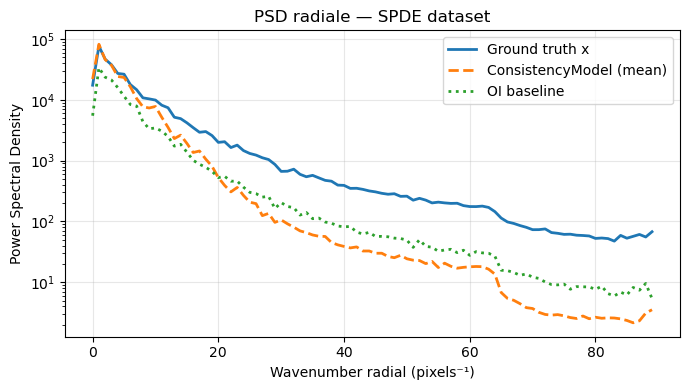

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(psd_gt_rad, label="Ground truth x",        linewidth=2)
ax.semilogy(psd_cm,      label="ConsistencyModel (mean)", linewidth=2, linestyle="--")
ax.semilogy(psd_oi,      label="OI baseline",            linewidth=2, linestyle=":")
ax.set_xlabel("Wavenumber radial (pixels⁻¹)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("PSD radiale — SPDE dataset")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparaison visuelle — GT / OI / ConsistencyModel (mean) / std ensemble

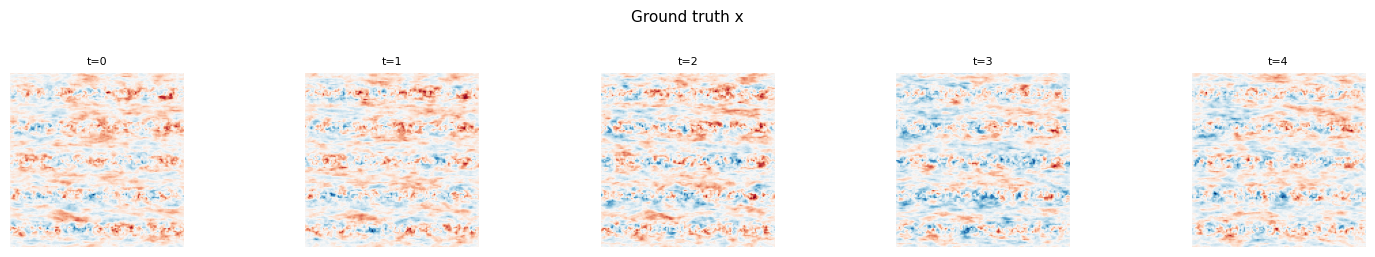

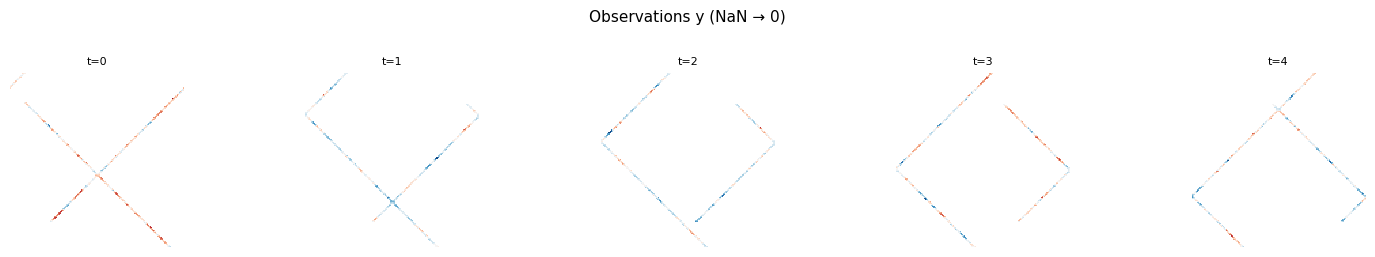

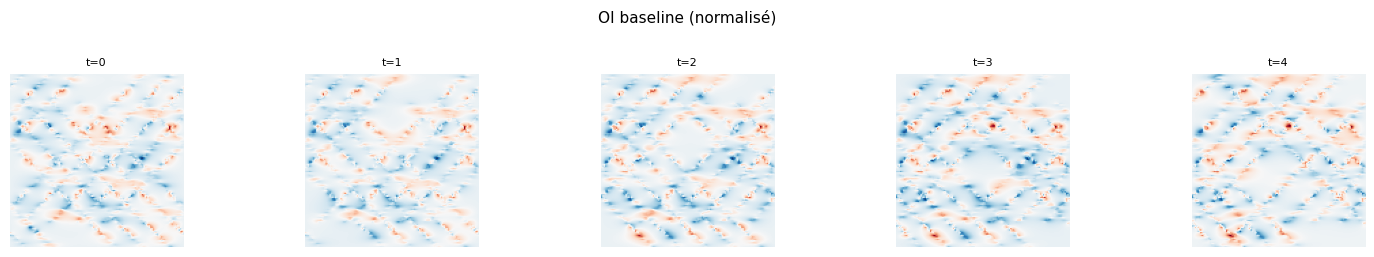

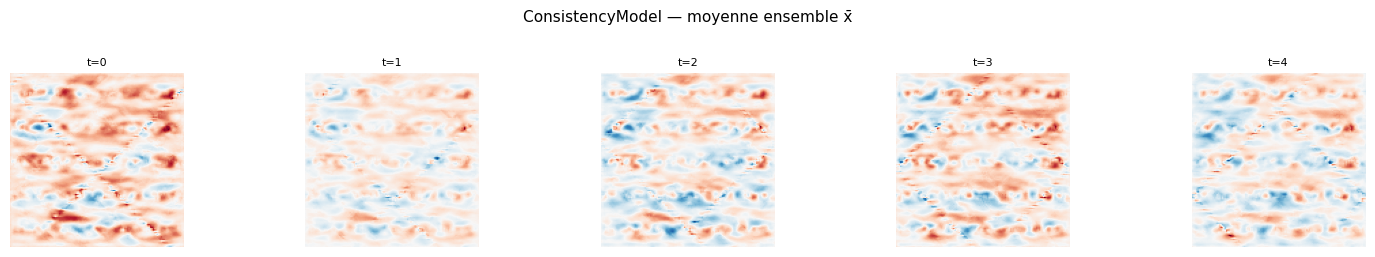

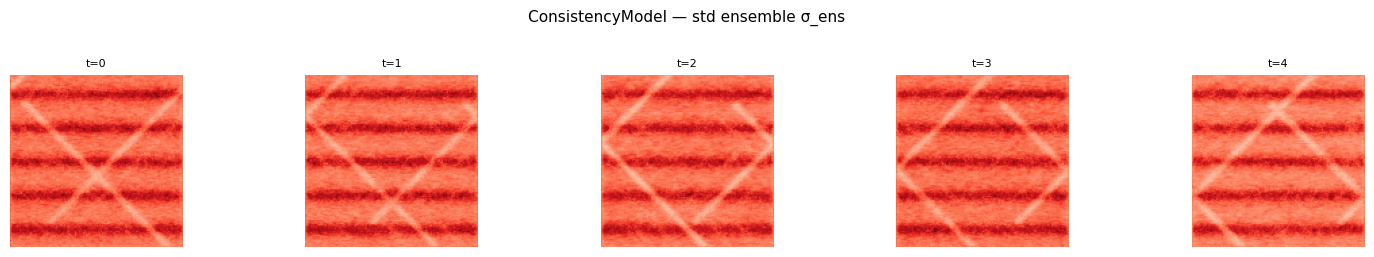

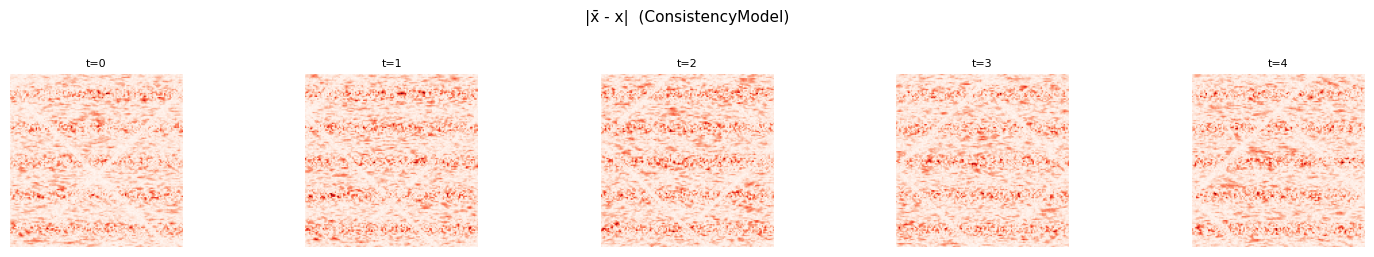

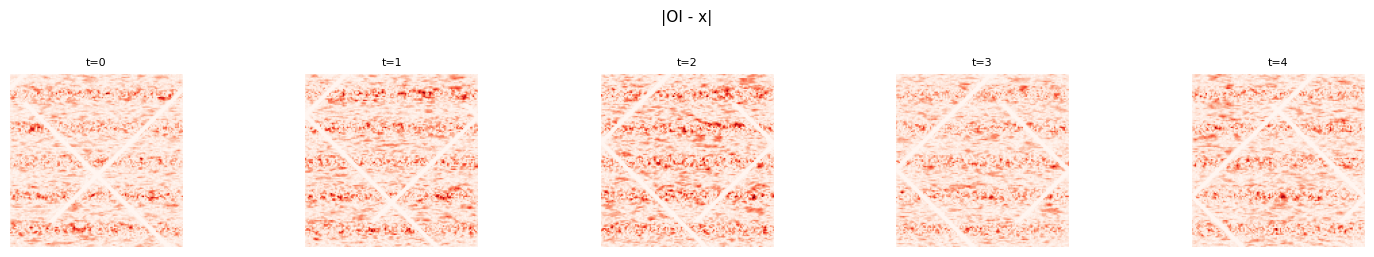

In [ ]:
plot_field(gt_np,                                             title="Ground truth x")
plot_field(batch.input[0].float().numpy(),                    title="Observations y (NaN → 0)")
plot_field(oi_norm,                                           title="OI baseline (normalisé)")
plot_field(ens_mean_np,                                       title="ConsistencyModel — moyenne ensemble x̄")
plot_field(ens_std.float().cpu().numpy(),                     title="ConsistencyModel — std ensemble σ_ens", vmin=0, cmap="Reds")
plot_field(np.abs(ens_mean_np - gt_np),                       title="|x̄ - x|  (ConsistencyModel)",         vmin=0, cmap="Reds")
plot_field(np.abs(oi_norm     - gt_np),                       title="|OI - x|",                              vmin=0, cmap="Reds")

### Processus de débruitage — membre 0 (étapes de sampling)

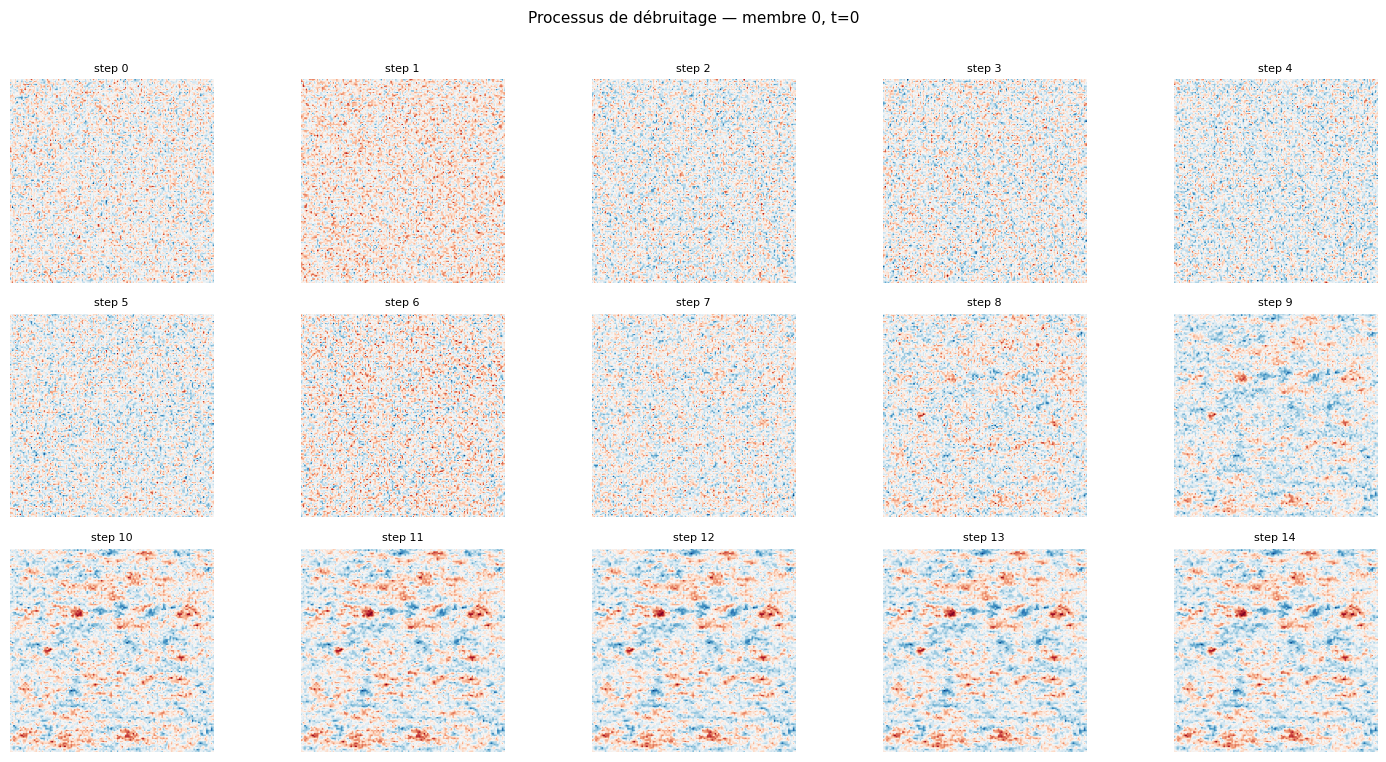

In [ ]:
# samples_process[0] : (nsteps, 1, C, H, W)
# On affiche l'évolution temporelle à t=0 au fil des étapes de sampling
process_t0 = samples_process[0][:, 0, 0, :, :]   # (nsteps, H, W)
process_np = process_t0.float().cpu().numpy()

nsteps = process_np.shape[0]
cols = min(nsteps, 5)
rows = math.ceil(nsteps / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
axes = np.array(axes).ravel()
for k in range(nsteps):
    axes[k].imshow(process_np[k], origin="lower", cmap="RdBu_r")
    axes[k].set_title(f"step {k}", fontsize=8)
    axes[k].axis("off")
for ax in axes[nsteps:]:
    ax.axis("off")
fig.suptitle("Processus de débruitage — membre 0, t=0", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()